__Основные команды Git__

1) git status

Отображает текущее состояние Git репозитория. Покажет какие файлы были изменены, добавлены и находятся в индексе

2) git add < files >

Подготовка файлов перед коммитом

3) git commit -m "< message >"

Создание коммита с записью изменений в репозиторий

-m позволяет указать сообщение, если его не указать, то нам нужно будет редактировать текстовый файл

4) git log

Просмотр истории изменений (коммитов)

git log --oneline позволяет вывести коммиты компактно

5) git checkout < commit hash >

Переход в определенную версию проекта по SHA1 хэшу коммита

6) git checkout < branch name >

также можно перейти в определенную ветку

7) git branch < branch name >

Создание ветки

также можно перейти в определенную ветку

если использовать флаг -b -> _git checkout -b < branch name > -> можно будет создать и переключиться

8) git branch

список веток

9) git branch -m < new branch name >

переименование текущей ветки

10) git branch -d < branch name >

Удаление ветки (текущую ветку удалить нельзя)

11) git merge < feature branch name >

Слияние веток (указываем ветку, которую мы хотим объединить с текущей)

feature branch (другой ветки) в текущую ветку (receiving branch) 

12) git init

инициализировать Git

13) git show < идентифкатор / ссылку >

Посмотреть конкретный коммит

А так можно читать содержимое объекта Git по его хэшу:

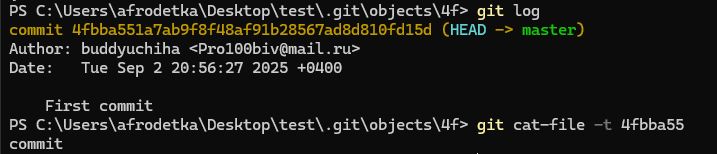

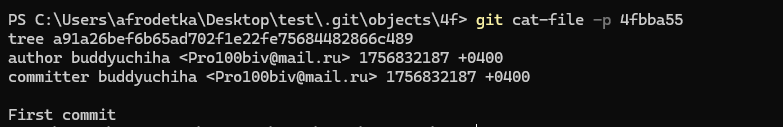

-t означает тип

-p означает содержимое

Вот так примерно выглядит содержимое root tree

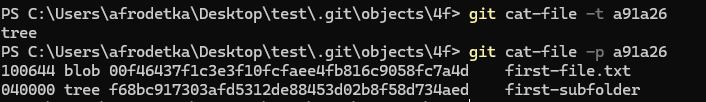

Вернуться в прошлую главную версию git checkout master


Чтоб писать коммиты через терминал и самому указывать большие комментарии к комиту необходимо:

1) git add .
2) git commit 

далее появится +- такое сообщение 

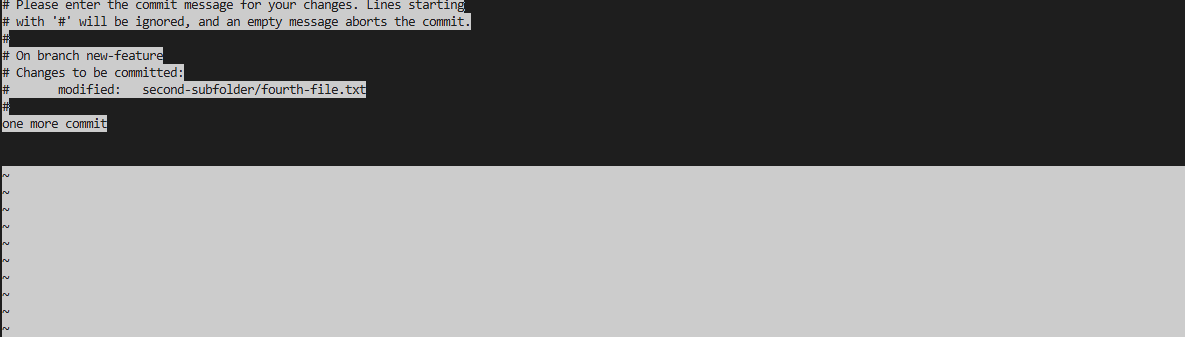

3) мы вписываем большое комментарий по коммиту 
4) нажимаем : и открывается косноль, где мы вводим wq (сохранить и выйти) или q! (просто выйти)

__Клонирование удаленных репозиториев__

git clone < url >

Git создает папку, в которую помещаются все файлы рабочий директории + создает подпапку .git

Для не публичных репозиториев нужны права

origin - имя удаленного репозитория по умолчанию

Чтоб увидеть ветки, котоыре созданы в удаленном репозитории:

git branch -a

Загрузка и применение изменений с удаленной ветки в локальную:

git pull

Загрузка изменений из локальной ветки в удаленную:

git push

Скачать новые объекты, но не применять изменения локалько:

git fetch

Чтоб автоматом открыть репозиторий через терминал:

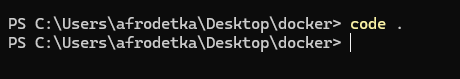

Чтоб проверить ссылки на уделанный репозиторий:

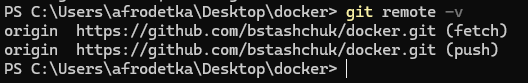

__Как связать существующий локальный репозиторий с удаленным репозиторием__

1) git remote add origin < url >

это подключение удаленного репозитория, где origin - это имя, а url ссылка на уже созданный репозиторий на github

2) git push -u origin < branch >

это загрузка изменений из локальной веткив удаленную с созданием связи между ними

3) git push

после установки связи веток дальнейшие загрузка изменений происходят через эту команду

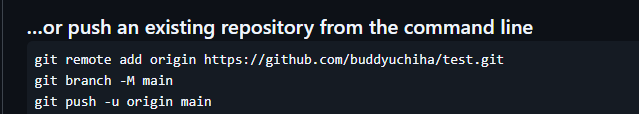

Если не зареганы, то надо будет вводить меил и пароль (токен разработчика)

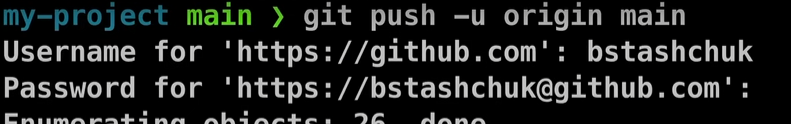

__Полезные остальные штуки__

Так можно узнать хэш основного коммита и вернуться к нему:

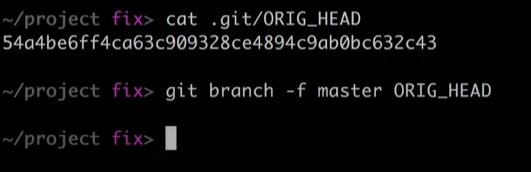

Посмотреть историю коммитов:

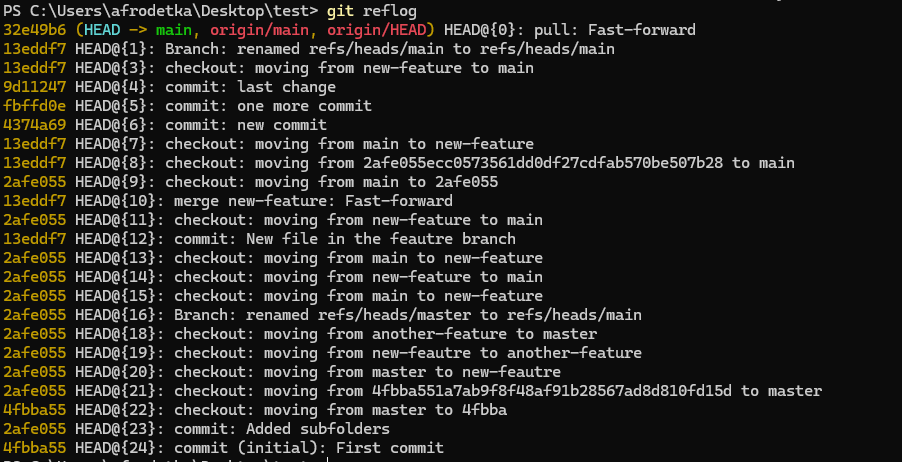

Удаление коммитов:

1) Жесткий ресет:

git reset --hard < хэш коммита>

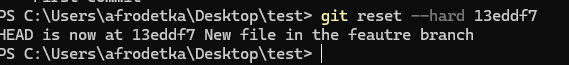

2) Мягкий ресет:

git reset --soft < хэш >

он не трогает рабочую директорию и индекс

Исправление последнего коммита:

git commint --amend

эт команда передвигает текущую ветку назад (все файлы остались как есть), а затем создает новый коммит используя новый текст

нужна чтоб добавить забытые файлы в последний коммит или поменять название коммита

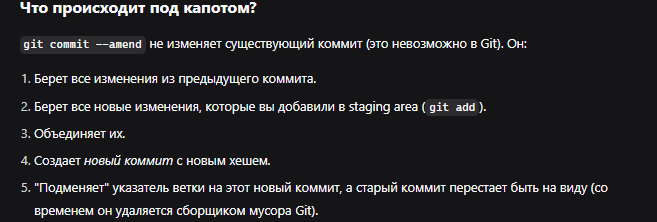

Перемещение коммитов или перебазирование веток:

git rebase

Наприме если в мастер добавили новые фичи, а у тебя коммит старый, то есть такая ситуация +-:

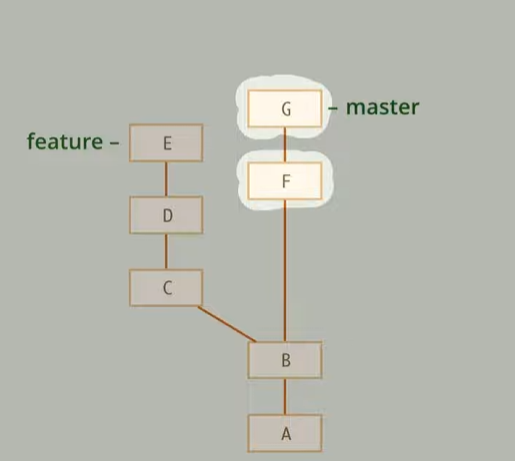

то можно перенести, используя git rebase master 

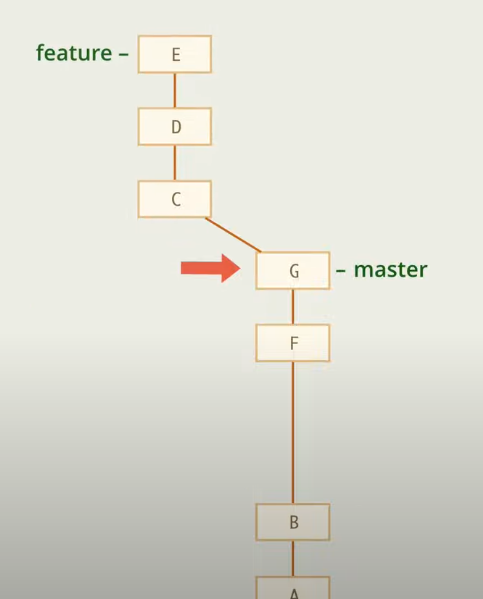

Ребейс копирует все коммиты из ветки feature поверх master

Чтоб разрешить конфликт нужно использовать:

git rebase --abort

Для отмены коммитов можно использовать: 

git revert < хэш >

git stash - место, куда можно временно скинуть изменения

git cherry-pick позволяет взять один конкретный коммит из одной ветки и скопировать в другую ветку

git squash помогает делать историю почище

__АВТОРИЗАЦИЯ__

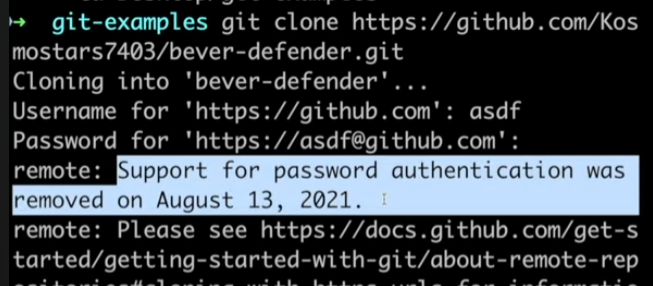

SSH (Secure Shell) — это безопасный способ подключения к удаленному серверу (например, к GitHub) и выполнения команд. Вся передаваемая информация шифруется.

Для авторизации по SSH вместо логина и пароля используется пара SSH-ключей.

Как работает SSH-авторизация? (Самая суть)
Это работает по принципу «замка и ключа».

У вас есть два ключа:

Приватный ключ (private key) — это ваш личный, секретный ключ. Его нельзя никому показывать и передавать! Он хранится только на вашем компьютере. (~/.ssh/id_rsa)

Публичный ключ (public key) — это открытая часть, которую можно свободно раздавать. Его можно публиковать где угодно. По нему невозможно восстановить приватный ключ. (~/.ssh/id_rsa.pub)

Проверка наличия ключей:

ls -al ~/.ssh

Создание:

ssh-keygen -t ed25519 -C "your_email@example.com"

Добавление на гитхаб:

cat ~/.ssh/id_ed25519.pub

Скопируйте весь вывод из терминала. Он выглядит примерно так:
ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAIJd7... ваш_email@example.com

Идите в настройки вашего аккаунта на GitHub:

GitHub: Settings -> SSH and GPG keys -> New SSH Key

GitLab: Preferences -> SSH Keys

Проверка:

ssh -T git@github.com

__последний гайд чайника__

1. Подготовка в VSCode:

Открой папку проекта.

git init в терминале.

Добавь файлы через иконку + на вкладке "Source Control".

Сделай коммит через галочку ✓ с сообщением.

2. Создание репозитория на GitHub:

Зайди на GitHub.com.

Нажми New.

Дай имя, выбери Public/Private.

Не создавай README, .gitignore и license!

Жми Create repository.

3. Связывание и отправка:

Скопируй команды из раздела …or push an existing repository.

Вставь в терминал VSCode:

git remote add origin [ссылка]

git push -u origin main

Готово. Код на GitHub.